In [1]:
import os
import numpy as np
#import matplotlib.pyplot as plt
#from ncmcm.data_loaders.matlab_dataset import Database
#from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser
from ncmcm.bundlenet.utils import timeseries_train_test_split

os.chdir('../..')
os.getcwd()


'/home/akshey/Desktop/PhD/Code_repositories/bundlenet_results'

bundlenet


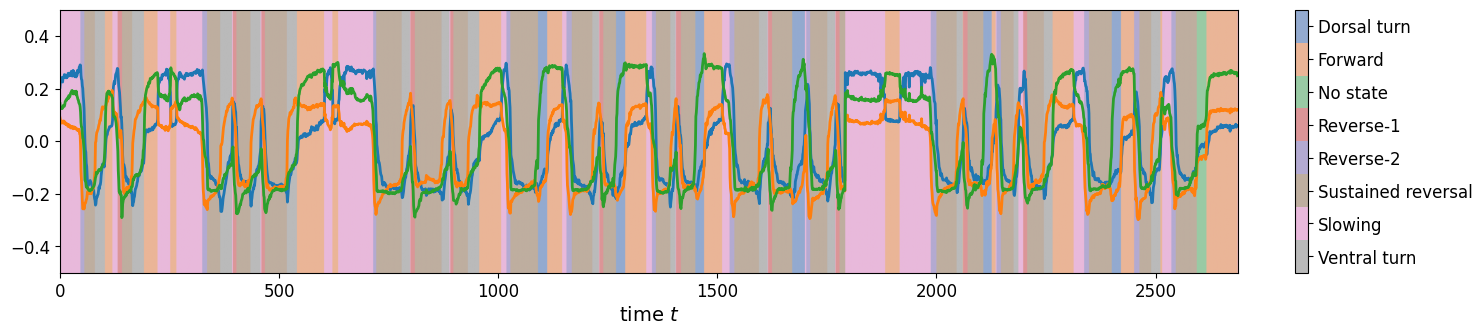

In [2]:
algorithm = 'bundlenet'
worm_num = 0
b_names = ['Dorsal turn', 'Forward', 'No state', 'Reverse-1', 'Reverse-2', 'Sustained reversal', 'Slowing', 'Ventral turn']
b_names = {idx:name for idx, name in enumerate(b_names)}

y0_train = np.loadtxt(f'data/generated/behaviour_vs_embedding/c_elegans/y0_train_{algorithm}_worm_{worm_num}')
b_train = np.loadtxt(f'data/generated/behaviour_vs_embedding/c_elegans/b_train_{algorithm}_worm_{worm_num}').astype(int)
print(algorithm)
vis = LatentSpaceVisualiser(
    y0_train, 
    b_train, 
    b_names, 
    show_points=True,
    legend=False
)
vis.plot_latent_timeseries()

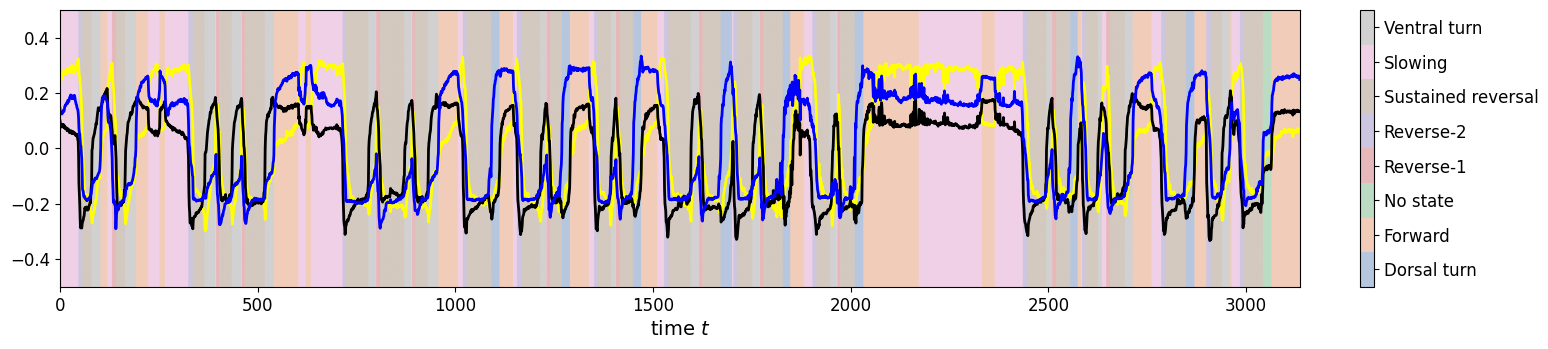

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
colors = sns.color_palette('deep', len(b_names))
cmap = ListedColormap(colors)
plt.figure(figsize=(20, 20))
im = plt.imshow(
    [b_], 
    aspect=700, 
    cmap=cmap,
    vmin=np.min(b_) - 0.5, 
    vmax=np.max(b_) + 0.5,
    alpha=0.4
)
cbar = plt.colorbar(
    im, 
    ticks=np.arange(np.min(b_), np.max(b_) + 1)
)

cbar.ax.set_yticklabels(list(b_names.values()), fontsize=12)
bbox = im.axes.get_position()  # bounding box of `imshow`
cbar.ax.set_position([bbox.x1 + 0.03, bbox.y0, 0.02, bbox.height])

# Distinct line colors not in the cmap
line_colors = ["yellow", "black", "blue"]

for i, color in enumerate(line_colors):
    plt.plot(
        y0_[:, i] / np.max(np.abs(y0_[:, i])) / 3,
        color=color,
        linewidth=2
    )
plt.xlabel("time $t$", fontsize=14)
plt.axis([0, y0_.shape[0], -0.5, 0.5])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()


bundlenet


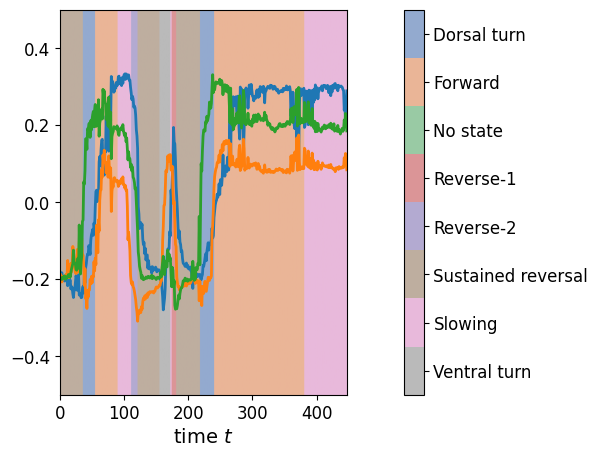

In [14]:
y0_test = np.loadtxt(f'data/generated/behaviour_vs_embedding/c_elegans/y0_test_{algorithm}_worm_{worm_num}')
b_test = np.loadtxt(f'data/generated/behaviour_vs_embedding/c_elegans/b_test_{algorithm}_worm_{worm_num}').astype(int)
print(algorithm)
vis = LatentSpaceVisualiser(
    y0_test, 
    b_test, 
    b_names, 
    show_points=True,
    legend=False
)
vis.plot_latent_timeseries()

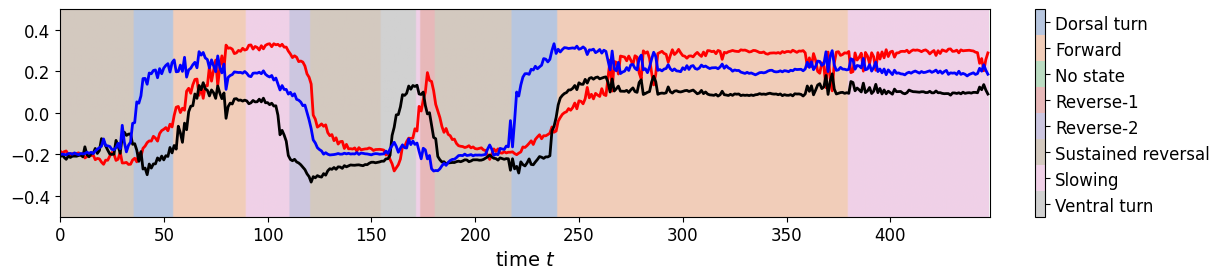

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
colors = sns.color_palette('deep', len(b_names))
cmap = ListedColormap(colors)
plt.figure(figsize=(15, 9))
im = plt.imshow(
    [b_test], 
    aspect=100, 
    cmap=cmap,
    vmin=np.min(b_test) - 0.5, 
    vmax=np.max(b_test) + 0.5,
    alpha=0.4
)
cbar = plt.colorbar(
    im, 
    ticks=np.arange(np.min(b_test), np.max(b_test) + 1)
)

cbar.ax.invert_yaxis() 
cbar.ax.set_yticklabels(list(b_names.values()), fontsize=12)
bbox = im.axes.get_position()  # bounding box of `imshow`
cbar.ax.set_position([bbox.x1 + 0.03, bbox.y0, 0.02, bbox.height])

# Distinct line colors not in the cmap
line_colors = ["red", "black", "blue"]

for i, color in enumerate(line_colors):
    plt.plot(
        y0_test[:, i] / np.max(np.abs(y0_test[:, i])) / 3,
        color=color,
        linewidth=2
    )
plt.xlabel("time $t$", fontsize=14)
plt.axis([0, y0_test.shape[0], -0.5, 0.5])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()


In [7]:

y0_ = np.loadtxt(f'data/generated/behaviour_vs_embedding/c_elegans/y0__{algorithm}_worm_{worm_num}')
b_ = np.loadtxt(f'data/generated/behaviour_vs_embedding/c_elegans/b__{algorithm}_worm_{worm_num}').astype(int)

from ncmcm.bundlenet.utils import timeseries_train_test_split
y0_.shape
_, test_indices, _, _ = timeseries_train_test_split(np.arange(y0_.shape[0]), np.arange(y0_.shape[0]))
print(test_indices[0], test_indices[-1])

1792 2239


bundlenet


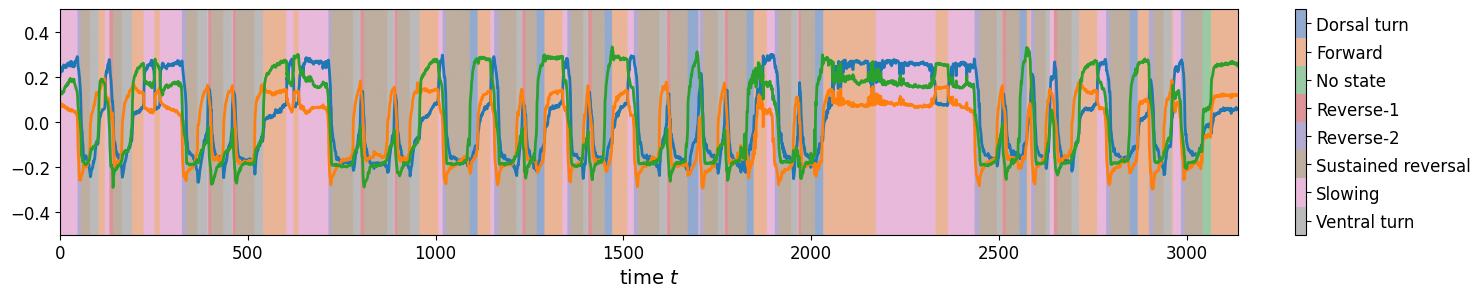

In [11]:

print(algorithm)
vis = LatentSpaceVisualiser(
    y0_, 
    b_, 
    b_names, 
    show_points=True,
    legend=False
)
vis.plot_latent_timeseries()

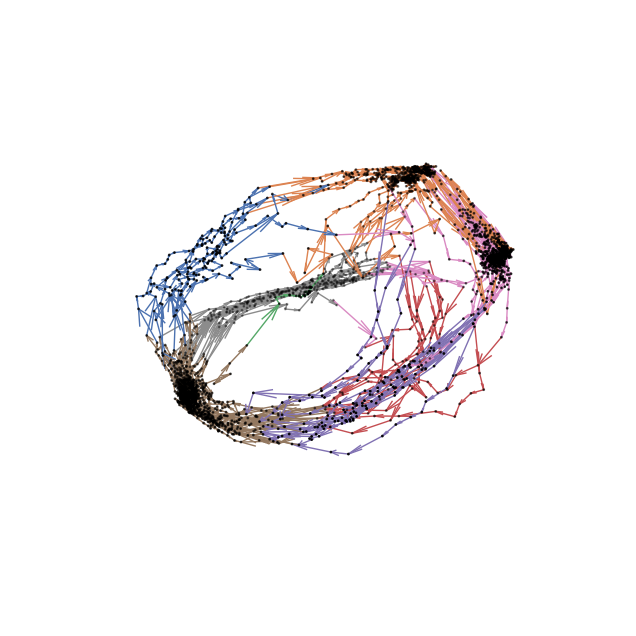

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [12]:
vis.plot_phase_space(arrow_length_ratio = 0.4)